In [1]:
import h5py

file_path = r"Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys:")
    for key in f.keys():
        print(key)

Keys:
X
Y
Z


In [2]:
with h5py.File(file_path, "r") as f:
    for key in f.keys():
        print(key, f[key].shape)

X (2555904, 1024, 2)
Y (2555904, 24)
Z (2555904, 1)


In [3]:
import h5py
import numpy as np



with h5py.File(file_path, "r") as f:
    X = f["X"]
    Y = f["Y"]
    Z = f["Z"]

    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Z shape:", Z.shape)

    print("\nFirst Y:")
    print(Y[0])

    print("\nFirst Z:")
    print(Z[0])

    print("\nX[0] shape:")
    print(X[0].shape)

    print("\nFirst 5 IQ samples:")
    print(X[0][:120])

X shape: (2555904, 1024, 2)
Y shape: (2555904, 24)
Z shape: (2555904, 1)

First Y:
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First Z:
[-20]

X[0] shape:
(1024, 2)

First 5 IQ samples:
[[ 4.20273952e-02  2.34763235e-01]
 [-2.72882611e-01  4.05134916e-01]
 [-2.67072618e-01  2.27498889e-01]
 [-3.14850867e-01 -1.76458597e-01]
 [ 9.63341236e-01 -1.02571023e+00]
 [ 1.87244624e-01  6.44536376e-01]
 [ 2.60705411e-01 -4.00602192e-01]
 [-1.38889417e-01  3.37220818e-01]
 [ 3.51226389e-01 -3.00818056e-01]
 [ 6.83884501e-01 -1.90601695e+00]
 [ 1.19307786e-01  7.23491237e-02]
 [-1.77766070e-01 -3.49935830e-01]
 [ 4.21254300e-02 -2.73146898e-01]
 [ 1.16819859e+00  1.35799253e+00]
 [ 1.13426137e+00  4.34401125e-01]
 [ 3.39727253e-02 -9.00930226e-01]
 [ 1.82389474e+00 -1.91117674e-01]
 [ 1.11155123e-01  3.19545120e-01]
 [ 8.38508904e-01  3.62890035e-01]
 [ 1.07418180e+00  3.98637831e-01]
 [ 3.25316995e-01 -5.00284135e-01]
 [-7.12064922e-01 -2.04506859e-01]
 [-5.76841295e-01  1.49948746e-01]
 [

In [4]:
f= h5py.File(file_path , "r")

In [5]:
X

<Closed HDF5 dataset>

In [6]:
import h5py

f = h5py.File("Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5", "r")
x = f["X"]
print(x[0].shape)

(1024, 2)


In [7]:
y= f["Y"]
z=f["Z"]
labels = np.argmax(y , axis = 1)

In [8]:
print("Class IDs:", np.unique(labels))

Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [9]:
import json
with open(r"Dataset/archive/classes-fixed.json" , "r") as f:
    classes = json.load(f)
print(classes)

['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [10]:
sample = x[319488][0]
sample

array([-0.50679684,  0.4923161 ], dtype=float32)

In [11]:
sample[:10]

array([-0.50679684,  0.4923161 ], dtype=float32)

In [12]:
label = np.argmax(y[319488])
snr = z[319488][0]

In [13]:
print("Class ID:", label)
print("Modulation:", classes[label])
print("SNR:", snr, "dB")

Class ID: 3
Modulation: BPSK
SNR: -20 dB


In [14]:
for i in [0, 4096, 8192, 106496, 106498]:
    print(i, np.argmax(y[i]), z[i][0])

0 0 -20
4096 0 -18
8192 0 -16
106496 1 -20
106498 1 -20


Text(0, 0.5, 'Amplitude')

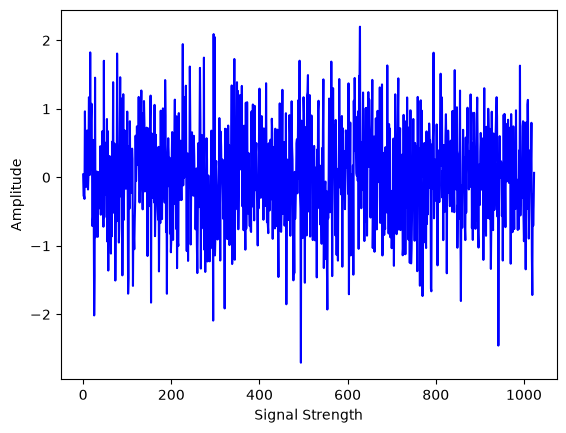

In [15]:
# Now I will plot te see how the signal works
import matplotlib.pyplot as plt
first = x[0]

plt.plot(first[: , 0] , color = "blue" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

Text(0, 0.5, 'Amplitude')

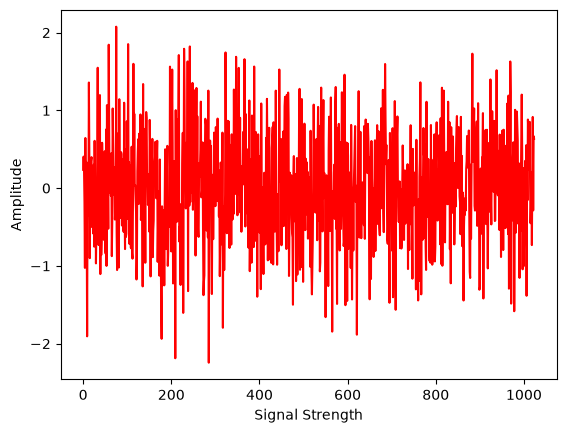

In [16]:
plt.plot( first[: ,1] , color = "red" )
plt.xlabel("Signal Strength")
plt.ylabel("Amplitude")

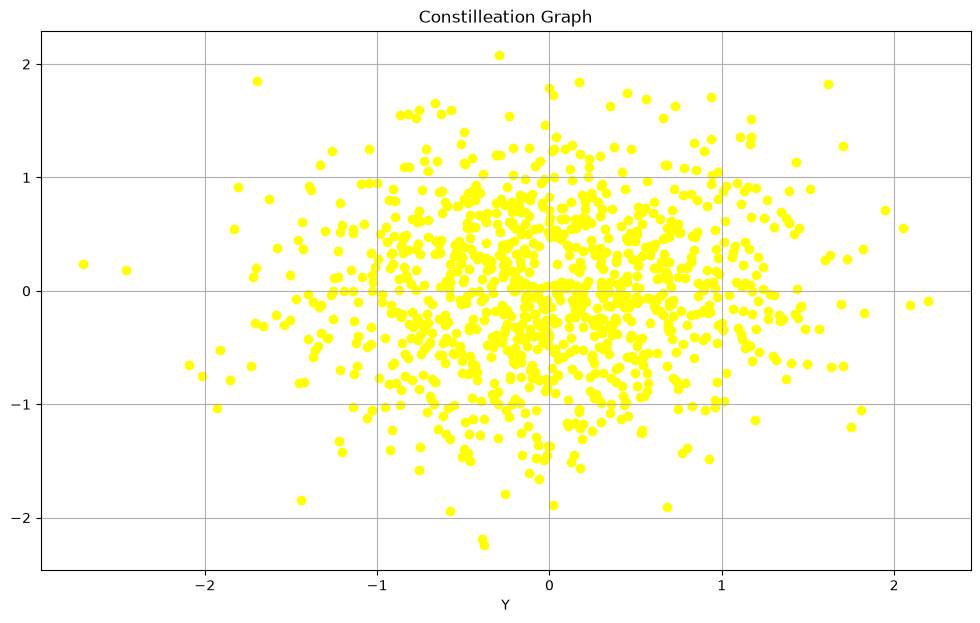

In [17]:
plt.figure(figsize=(12,7))
plt.scatter(first[: , 0] , first[: ,1] , color = "yellow" )

plt.xlabel("X")
plt.xlabel("Y")
plt.title("Constilleation Graph")

plt.grid()


In [18]:
for i in [0,100,189000,10000,969999]:
    label = np.argmax(y[i])
    snr = z[i][0]
    print(f"{i}-->{classes[label]} --> {snr}"
        
    )
    


0-->OOK --> -20
100-->OOK --> -20
189000-->4ASK --> 20
10000-->OOK --> -16
969999-->32APSK --> -16


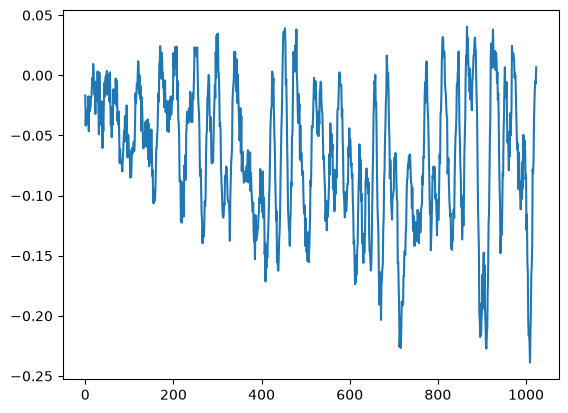

In [19]:
g = 189000
s1 = x[g]
i = s1[: , 0]
q=s1[: ,1]
plt.plot(i)

In [20]:
print(np.unique(z))

[-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


In [21]:
for i in np.unique(z[:,0]):
    count = np.sum(z[:, 0] == i)
    print(f"{i} --> {count}")

-20 --> 98304
-18 --> 98304
-16 --> 98304
-14 --> 98304
-12 --> 98304
-10 --> 98304
-8 --> 98304
-6 --> 98304
-4 --> 98304
-2 --> 98304
0 --> 98304
2 --> 98304
4 --> 98304
6 --> 98304
8 --> 98304
10 --> 98304
12 --> 98304
14 --> 98304
16 --> 98304
18 --> 98304
20 --> 98304
22 --> 98304
24 --> 98304
26 --> 98304
28 --> 98304
30 --> 98304


In [22]:
for g in np.unique(labels):
    count = np.sum(labels == g)
    print(f"{classes[g]}--> {count}")

OOK--> 106496
4ASK--> 106496
8ASK--> 106496
BPSK--> 106496
QPSK--> 106496
8PSK--> 106496
16PSK--> 106496
32PSK--> 106496
16APSK--> 106496
32APSK--> 106496
64APSK--> 106496
128APSK--> 106496
16QAM--> 106496
32QAM--> 106496
64QAM--> 106496
128QAM--> 106496
256QAM--> 106496
AM-SSB-WC--> 106496
AM-SSB-SC--> 106496
AM-DSB-WC--> 106496
AM-DSB-SC--> 106496
FM--> 106496
GMSK--> 106496
OQPSK--> 106496


In [23]:
for i in range (0,500000 , 50000):
    label = np.argmax(y[i])
    print(label)

0
0
0
1
1
2
2
3
3
4


In [24]:
no=1096
label = np.argmax(y[no])
label
classes[label]

'OOK'

In [25]:
x[0]


array([[ 0.0420274 ,  0.23476323],
       [-0.2728826 ,  0.40513492],
       [-0.26707262,  0.22749889],
       ...,
       [-0.7055947 , -0.28693035],
       [-0.41157472,  0.66826206],
       [ 0.06487698,  0.6358149 ]], shape=(1024, 2), dtype=float32)

In [26]:
for i in range (0 , 100):
    for j in [0]:
        val = x[0][i][j]
        val1 = x[0][i][j+1]
        d = (val)**2 + (val)**2
        print(np.sqrt(d))
        
        

0.05943571
0.3859143
0.3776977
0.44526637
1.3623703
0.2648039
0.3686931
0.1964193
0.49670914
0.96715873
0.1687267
0.2513992
0.059574354
1.6520823
1.6040878
0.04804469
2.5793767
0.15719709
1.1858306
1.5191225
0.4600677
1.0070119
0.81577677
0.77156436
0.7150778
2.8514025
2.0310934
2.0572903
1.2367038
0.5590294
0.28267258
0.11899959
0.13456924
1.2297359
0.11079021
0.12262378
0.03480202
0.6383308
0.40940446
0.6425057
0.772211
0.020265548
0.2813293
0.2084861
0.9574126
0.31036985
1.0199449
2.4065344
0.8274865
0.06459589
0.030100146
0.71447784
0.3642017
0.3082762
1.2040268
1.328984
0.9536538
1.9247203
0.242059
0.75298667
0.4395975
0.20485796
0.8158514
1.5747147
0.3388151
1.2180427
0.7372664
0.3026245
1.9643414
0.35425064
0.7335391
0.69804406
0.0001913834
2.1310523
0.9066715
0.40986744
0.9062957
2.5556962
0.75518095
0.21314935
0.60826325
1.3463455
1.0311958
0.8055839
2.0663264
0.39280742
0.95077735
0.29445612
1.628492
2.0242887
0.09346916
1.7165192
0.8807573
0.11622352
0.96999675
0.08409884
0.

In [27]:
no_of_samples = 106496
samples_per_snr = 4096
sample_take = 150
X_list = []
Y_list = []
Z_list = []
for class_id in range (24):
    class_start = no_of_samples * class_id
    for snr_id in range (26):
        start = class_start + snr_id*samples_per_snr
        end = start + sample_take
        X_list.append(x[start:end])
        Y_list.append(y[start:end])
        Z_list.append(z[start:end])
X_subset = np.concatenate(X_list , axis=0)
Y_subset = np.concatenate(Y_list , axis=0)
Z_subset = np.concatenate(Z_list , axis=0)
        
        
    

In [28]:
print("X_subset:", X_subset.shape)
print("Y_subset:", Y_subset.shape)
print("Z_subset:", Z_subset.shape)

X_subset: (93600, 1024, 2)
Y_subset: (93600, 24)
Z_subset: (93600, 1)


In [29]:
Y_subset

array([[1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]], shape=(93600, 24))

In [30]:
label1 = np.argmax(Y_subset , axis=1)


In [31]:
#  Amplitude for the extracted data 
I = X_subset[: , : ,0]
Q = X_subset[: , : ,1]
amplitude = np.sqrt(I**2+Q**2)
amplitude.shape

(93600, 1024)

In [32]:
import numpy as np
import pandas as pd

from scipy.stats import skew as scipy_skew
from scipy.stats import kurtosis as scipy_kurtosis
amp = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)

# Unwrapped phase for instantaneous frequency
phase_unwrapped = np.unwrap(phase, axis=1)


# 2. Basic Amplitude Statistics
amp_mean = amp.mean(axis=1)
amp_std = amp.std(axis=1)
amp_max = amp.max(axis=1)
amp_min = amp.min(axis=1)
amp_ptp = amp_max - amp_min
amp_var = amp_std**2


# 3. Power & Ratios
power = np.mean(I**2 + Q**2, axis=1)

RMS_amp = np.sqrt(power)

crest_factor = amp_max / (RMS_amp + 1e-12)

papr = 10 * np.log10(
    (amp_max**2) / (power + 1e-12)
)


# 4. Instantaneous Frequency
inst_freq = np.diff(phase_unwrapped, axis=1)

inst_freq_mean = inst_freq.mean(axis=1)
inst_freq_std = inst_freq.std(axis=1)


# 5. Higher-Order Amplitude Moments

amp_mean_col = amp.mean(axis=1, keepdims=True)
amp_centered = amp - amp_mean_col

amp_skew = (
    np.mean(amp_centered**3, axis=1)
    / (amp_std**3 + 1e-12)
)

amp_kurtosis = (
    np.mean(amp_centered**4, axis=1)
    / (amp_std**4 + 1e-12)
    - 3
)


# 6. Scipy Skewness & Kurtosis
# Use aliases so they cannot conflict with variables named
# skew or kurtosis elsewhere in the notebook.

amp_kurt = scipy_kurtosis(amp, axis=1)

I_skew = scipy_skew(I, axis=1)
Q_skew = scipy_skew(Q, axis=1)


# 7. Feature Names
feature_names = [
    "I_mean",
    "I_std",
    "Q_mean",
    "Q_std",
    "amp_mean",
    "amp_std",
    "amp_max",
    "phase_mean",
    "phase_std",
    "power",
    "RMS_amp",
    "amp_var",
    "amp_skew",
    "amp_kurtosis",
    "amp_min",
    "amp_ptp",
    "amp_kurt",
    "I_skew",
    "Q_skew",
    "crest_factor",
    "papr",
    "inst_freq_mean",
    "inst_freq_std",
]


# 8. Stack Features
features = np.column_stack([
    I.mean(axis=1),
    I.std(axis=1),

    Q.mean(axis=1),
    Q.std(axis=1),

    amp_mean,
    amp_std,
    amp_max,

    phase.mean(axis=1),
    phase.std(axis=1),

    power,
    RMS_amp,
    amp_var,

    amp_skew,
    amp_kurtosis,

    amp_min,
    amp_ptp,
    amp_kurt,

    I_skew,
    Q_skew,

    crest_factor,
    papr,

    inst_freq_mean,
    inst_freq_std
])


# 9. Create DataFrame
df_features = pd.DataFrame(
    features,
    columns=feature_names
)




In [33]:
from sklearn.model_selection import train_test_split

X = df_features.values
y = np.asarray(label1).ravel()

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)
print("Number of classes:", len(np.unique(y)))

Train shape: (74880, 23)
Test shape : (18720, 23)
Number of classes: 24


In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

xg = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    n_jobs=-1,
    random_state=42
)

xg.fit(x_train, y_train)

xgb_pred = xg.predict(x_test)

print("XGBoost Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred, average="macro"))
print("Recall   :", recall_score(y_test, xgb_pred, average="macro"))
print("F1       :", f1_score(y_test, xgb_pred, average="macro"))

XGBoost Results
----------------------------------------
Accuracy : 0.41623931623931626
Precision: 0.40367970027358585
Recall   : 0.41623931623931626
F1       : 0.4086224823218855


In [35]:
from sklearn.linear_model import LogisticRegression


In [36]:
from sklearn.neighbors import KNeighborsClassifier


In [37]:
lr = LogisticRegression(max_iter=2000,
    random_state=42)





In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Scaled training shape:", x_train_scaled.shape)
print("Scaled testing shape :", x_test_scaled.shape)

Scaled training shape: (74880, 23)
Scaled testing shape : (18720, 23)


In [39]:
lr.fit(x_train_scaled , y_train)
lr_pred =lr.predict(x_test_scaled)
print(accuracy_score(y_test , lr_pred))
print(f1_score(y_test , lr_pred , average="macro"))
print(precision_score(y_test , lr_pred , average="macro"))
print(recall_score(y_test , lr_pred , average="macro"))

0.36527777777777776
0.34267437697675357
0.3522895035047628
0.36527777777777776


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

rf.fit(x_train, y_train)

rf_pred = rf.predict(x_test)

print("Random Forest Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred, average="macro"))
print("Recall   :", recall_score(y_test, rf_pred, average="macro"))
print("F1       :", f1_score(y_test, rf_pred, average="macro"))

Random Forest Results
----------------------------------------
Accuracy : 0.4096688034188034
Precision: 0.4079813169022055
Recall   : 0.4096688034188034
F1       : 0.40777789565002726


In [41]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(
    n_neighbors=23,
    weights="uniform",
    metric="euclidean",
    n_jobs=-1
)

knn.fit(x_train_scaled, y_train)

knn_pred = knn.predict(x_test_scaled)

print("KNN Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, knn_pred))
print("Precision:", precision_score(y_test, knn_pred, average="macro"))
print("Recall   :", recall_score(y_test, knn_pred, average="macro"))
print("F1       :", f1_score(y_test, knn_pred, average="macro"))

KNN Results
----------------------------------------
Accuracy : 0.31490384615384615
Precision: 0.3288760504729244
Recall   : 0.31490384615384615
F1       : 0.31881222197288955


In [42]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(
    n_estimators=300,
    learning_rate=0.1,
    random_state=42
)

ada.fit(x_train, y_train)

ada_pred = ada.predict(x_test)

print("AdaBoost Results")
print("-" * 40)
print("Accuracy :", accuracy_score(y_test, ada_pred))
print("Precision:", precision_score(y_test, ada_pred, average="macro"))
print("Recall   :", recall_score(y_test, ada_pred, average="macro"))
print("F1       :", f1_score(y_test, ada_pred, average="macro"))

AdaBoost Results
----------------------------------------
Accuracy : 0.15721153846153846
Precision: 0.159550042480023
Recall   : 0.15721153846153846
F1       : 0.10761190761404182


C:\Users\mishr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [43]:
results = pd.DataFrame({
    "Model": [
        "XGBoost",
        "KNN",
        "Logistic Regression",
        "Random Forest",
        "AdaBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred)
    ],
    "Precision": [
        precision_score(y_test, xgb_pred, average="macro"),
        precision_score(y_test, knn_pred, average="macro"),
        precision_score(y_test, lr_pred, average="macro"),
        precision_score(y_test, rf_pred, average="macro"),
        precision_score(y_test, ada_pred, average="macro")
    ],
    "Recall": [
        recall_score(y_test, xgb_pred, average="macro"),
        recall_score(y_test, knn_pred, average="macro"),
        recall_score(y_test, lr_pred, average="macro"),
        recall_score(y_test, rf_pred, average="macro"),
        recall_score(y_test, ada_pred, average="macro")
    ],
    "F1": [
        f1_score(y_test, xgb_pred, average="macro"),
        f1_score(y_test, knn_pred, average="macro"),
        f1_score(y_test, lr_pred, average="macro"),
        f1_score(y_test, rf_pred, average="macro"),
        f1_score(y_test, ada_pred, average="macro")
    ]
})

results

C:\Users\mishr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1
0,XGBoost,0.416239,0.403680,0.416239,0.408622
1,KNN,0.314904,0.328876,0.314904,0.318812
2,Logistic Regression,0.365278,0.352290,0.365278,0.342674
3,Random Forest,0.409669,0.407981,0.409669,0.407778
4,AdaBoost,0.157212,0.159550,0.157212,0.107612


In [44]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


In [45]:
# Original IQ data
X_raw = X_subset.astype(np.float32)
y_raw = np.asarray(label1).astype(np.int64)

print("Raw IQ shape:", X_raw.shape)
print("Labels shape:", y_raw.shape)

Raw IQ shape: (93600, 1024, 2)
Labels shape: (93600,)


## Phase 2 — Self-Supervised Contrastive Pretraining + Open-Set Detection

**Scope for this abstract:** RadioML 2018.01A only. Near-neighbor open-set split — `64QAM` held out entirely as "unknown," the rest of the QAM family (16/32/128/256QAM) plus all other classes stay "known." No labels are used during pretraining, only during the linear probe and for building known-class centroids.

Cross-domain (DroneRF/CardRF) is explicitly out of scope here — future work only.


In [46]:
# --- Load known/unknown split directly from the HDF5 file (fixes the X_raw/y_raw
#     length mismatch from cell 57 -- we no longer rely on the stale `label1` var) ---

import json
import numpy as np
import h5py

with open(r"Dataset/archive/classes-fixed.json", "r") as f:
    CLASS_NAMES = json.load(f)   # list of 24 modulation names, index = class_id

NUM_CLASSES = len(CLASS_NAMES)
SAMPLES_PER_CLASS = 106496   # fixed layout of RadioML 2018.01A
SNRS_PER_CLASS = 26
SAMPLES_PER_SNR = 4096

# --- near-neighbor open-set split ---
UNKNOWN_CLASS_NAMES = ["64QAM"]          # held out entirely -- never seen in pretraining or probing
KNOWN_CLASS_NAMES = [c for c in CLASS_NAMES if c not in UNKNOWN_CLASS_NAMES]

UNKNOWN_IDS = [CLASS_NAMES.index(c) for c in UNKNOWN_CLASS_NAMES]
KNOWN_IDS = [CLASS_NAMES.index(c) for c in KNOWN_CLASS_NAMES]

print(f"Known classes ({len(KNOWN_IDS)}):", KNOWN_CLASS_NAMES)
print(f"Unknown (held-out) classes ({len(UNKNOWN_IDS)}):", UNKNOWN_CLASS_NAMES)

# how many samples to pull per (class, SNR) bin -- bump this up later once the
# pipeline runs end to end; 300/bin keeps the first pass fast
SAMPLES_PER_BIN = 500  # bumped up for a richer encoder

def load_class_block(f, class_id, samples_per_bin=SAMPLES_PER_BIN):
    """Load samples_per_bin examples from every SNR bin for one class_id.
    Returns (X: [n,1024,2] float32, snr: [n] int, label: [n] int)."""
    X_list, snr_list = [], []
    class_start = SAMPLES_PER_CLASS * class_id
    for snr_id in range(SNRS_PER_CLASS):
        start = class_start + snr_id * SAMPLES_PER_SNR
        end = start + samples_per_bin
        X_list.append(f["X"][start:end])
        snr_list.append(f["Z"][start:end, 0])
    X = np.concatenate(X_list, axis=0).astype(np.float32)
    snr = np.concatenate(snr_list, axis=0).astype(np.int64)
    label = np.full(len(X), class_id, dtype=np.int64)
    return X, snr, label

with h5py.File(file_path, "r") as f:
    known_X, known_snr, known_y = [], [], []
    for cid in KNOWN_IDS:
        Xc, snrc, yc = load_class_block(f, cid)
        known_X.append(Xc); known_snr.append(snrc); known_y.append(yc)
    known_X = np.concatenate(known_X, axis=0)
    known_snr = np.concatenate(known_snr, axis=0)
    known_y = np.concatenate(known_y, axis=0)

    unknown_X, unknown_snr, unknown_y = [], [], []
    for cid in UNKNOWN_IDS:
        Xc, snrc, yc = load_class_block(f, cid)
        unknown_X.append(Xc); unknown_snr.append(snrc); unknown_y.append(yc)
    unknown_X = np.concatenate(unknown_X, axis=0)
    unknown_snr = np.concatenate(unknown_snr, axis=0)
    unknown_y = np.concatenate(unknown_y, axis=0)

print("Known X:", known_X.shape, "| Unknown X:", unknown_X.shape)


Known classes (23): ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']
Unknown (held-out) classes (1): ['64QAM']
Known X: (299000, 1024, 2) | Unknown X: (13000, 1024, 2)


In [47]:
# --- train/val/test split for known classes (stratified by class), plus a held-out
#     test split for the unknown class. Unknown data is NEVER used in pretraining
#     or in the linear probe -- only at open-set evaluation time. ---

from sklearn.model_selection import train_test_split

SEED = 42

k_train_idx, k_temp_idx = train_test_split(
    np.arange(len(known_X)), test_size=0.30, random_state=SEED, stratify=known_y
)
k_val_idx, k_test_idx = train_test_split(
    k_temp_idx, test_size=0.5, random_state=SEED, stratify=known_y[k_temp_idx]
)

X_train, y_train, snr_train = known_X[k_train_idx], known_y[k_train_idx], known_snr[k_train_idx]
X_val,   y_val,   snr_val   = known_X[k_val_idx],   known_y[k_val_idx],   known_snr[k_val_idx]
X_test,  y_test,  snr_test  = known_X[k_test_idx],  known_y[k_test_idx],  known_snr[k_test_idx]

# unknown data only used at test time
X_unk, y_unk, snr_unk = unknown_X, unknown_y, unknown_snr

print("Train:", X_train.shape, "Val:", X_val.shape, "Test (known):", X_test.shape, "Test (unknown):", X_unk.shape)


Train: (209300, 1024, 2) Val: (44850, 1024, 2) Test (known): (44850, 1024, 2) Test (unknown): (13000, 1024, 2)


In [48]:
# --- import dataset/model/augmentation code from iq_utils.py ---
# (moved out of notebook cells into a real .py file so DataLoader(num_workers>0)
#  works on Windows: worker processes need to `import` this cleanly, not
#  re-execute notebook cell state)
from iq_utils import (
    time_shift, phase_rotation, noise_injection, channel_distortion, augment,
    ContrastiveIQDataset, LabeledIQDataset, IQEncoder, ProjectionHead, nt_xent_loss
)
from torch.utils.data import DataLoader


In [49]:
# --- DEBUG VERSION - Find where it's hanging ---

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

print("="*50)
print("DEBUG: Starting training...")
print("="*50)

# Check device
print(f"1. Device: {device}")
print(f"2. CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"3. GPU: {torch.cuda.get_device_name(0)}")
    print(f"4. VRAM: {torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

# Check data
print(f"5. X_train shape: {X_train.shape}")
print(f"6. Dataset size: {len(train_contrastive_ds)}")

# Check loader
print(f"7. Loader batches: {len(train_contrastive_loader)}")

# TEST: Try loading one batch
print("\n8. Testing data loader (this should be instant)...")
try:
    test_batch = next(iter(train_contrastive_loader))
    print(f"   ✓ Batch loaded! Shape: {test_batch[0].shape}")
    print(f"   ✓ Batch on CPU, moving to GPU now...")
    x1, x2 = test_batch[0].to(device), test_batch[1].to(device)
    print(f"   ✓ Moved to {device}")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

# Test model forward pass
print("\n9. Testing model forward pass...")
try:
    with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
        z1 = proj_head(encoder(x1))
        z2 = proj_head(encoder(x2))
        loss = nt_xent_loss(z1, z2)
    print(f"   ✓ Forward pass successful! Loss: {loss.item():.4f}")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

# Test backward pass
print("\n10. Testing backward pass...")
try:
    optimizer.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    print(f"   ✓ Backward pass successful!")
except Exception as e:
    print(f"   ✗ ERROR: {e}")
    raise

print("\n" + "="*50)
print("✅ ALL TESTS PASSED! Training should work now.")
print("="*50)
print("\nStarting actual training...")

# NOW RUN THE ACTUAL TRAINING WITH PROGRESS BAR
from tqdm import tqdm

pretrain_losses = []
best_loss = float("inf")
patience, patience_counter = 8, 0

for epoch in range(EPOCHS):
    encoder.train()
    proj_head.train()
    running_loss = 0.0
    
    # ADD TQDM PROGRESS BAR
    pbar = tqdm(train_contrastive_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for batch_idx, (x1, x2) in enumerate(pbar):
        x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)

        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))
            loss = nt_xent_loss(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    avg_loss = running_loss / len(train_contrastive_loader)
    pretrain_losses.append(avg_loss)
    
    if epoch % 5 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch+1}/{EPOCHS} | contrastive loss: {avg_loss:.4f}")

    # Early stopping
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_counter = 0
        best_encoder_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (loss plateaued)")
            break

# Restore best checkpoint
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    print("Loaded best encoder state from early stopping")

plt.plot(pretrain_losses)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.title("SimCLR Pretraining Loss")
plt.grid(alpha=0.3)
plt.show()

DEBUG: Starting training...
1. Device: cuda
2. CUDA available: True
3. GPU: NVIDIA GeForce RTX 4050 Laptop GPU
4. VRAM: 6.0 GB
5. X_train shape: (209300, 1024, 2)


NameError: name 'train_contrastive_ds' is not defined

Original data size: 209300
Subset data size: 90000
Batches per epoch: 351
Estimated time per epoch: ~10-15 seconds

Starting training...


Epoch 1/30: 100%|██████████| 351/351 [01:10<00:00,  5.00it/s, loss=4.7225]


Epoch 1/30 | contrastive loss: 4.8970


Epoch 2/30: 100%|██████████| 351/351 [01:10<00:00,  4.96it/s, loss=4.5949]


Epoch 2/30 | contrastive loss: 4.6467


...

Epoch 28/30 | contrastive loss: 4.4402


Epoch 29/30: 100%|██████████| 351/351 [01:16<00:00,  4.57it/s, loss=4.4320]


Epoch 29/30 | contrastive loss: 4.4413


Epoch 30/30: 100%|██████████| 351/351 [01:16<00:00,  4.59it/s, loss=4.4382]

Epoch 30/30 | contrastive loss: 4.4402
Loaded best encoder state from early stopping

Training complete! Plotting loss...


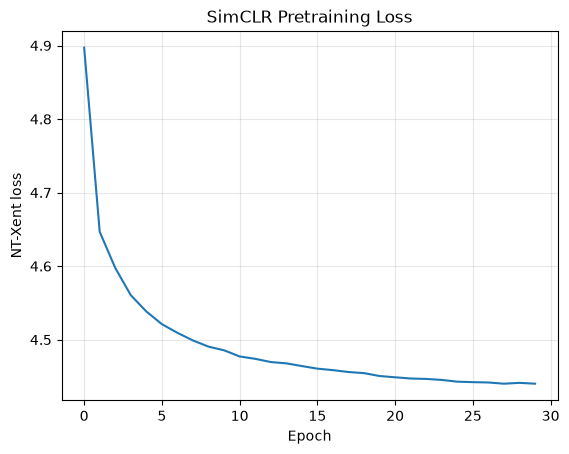

In [51]:
# --- Contrastive pretraining on KNOWN classes only, no labels used ---
# Uses mixed precision (AMP): faster and lighter on your GPU/laptop for the same work.

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Install tqdm if not present
try:
    from tqdm import tqdm
except ImportError:
    print("Installing tqdm...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'tqdm', '-q'])
    from tqdm import tqdm

# FIXED: nt_xent_loss with float16 compatibility
def nt_xent_loss(z1, z2, temperature=0.5):
    """Normalized Temperature-scaled Cross Entropy Loss - Fixed for AMP"""
    B = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)  # (2*batch_size, proj_dim)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * B, dtype=torch.bool, device=z.device)
    # FIXED: -1e4 instead of -1e9 (float16 can handle -1e4)
    sim = sim.masked_fill(mask, -1e4)
    targets = torch.cat([torch.arange(B, 2 * B), torch.arange(0, B)]).to(z.device)
    return F.cross_entropy(sim, targets)

# ============= REDUCED DATA SIZE FOR LAPTOP =============
SUBSET_SIZE = 90000  # Use 20k samples instead of 209k
print(f"Original data size: {len(X_train)}")
np.random.seed(42)
indices = np.random.choice(len(X_train), SUBSET_SIZE, replace=False)
X_train_subset = X_train[indices]
y_train_subset = y_train[indices]
snr_train_subset = snr_train[indices]
print(f"Subset data size: {len(X_train_subset)}")

BATCH_SIZE = 256  # Reduced from 512 for faster iteration
EMBED_DIM = 128
PROJ_DIM = 64
EPOCHS = 30  # Reduced from 50
LR = 3e-4

train_contrastive_ds = ContrastiveIQDataset(X_train_subset)
train_contrastive_loader = DataLoader(train_contrastive_ds, batch_size=BATCH_SIZE,
                                       shuffle=True, num_workers=0, drop_last=True,
                                       pin_memory=True)

print(f"Batches per epoch: {len(train_contrastive_loader)}")
print(f"Estimated time per epoch: ~10-15 seconds")
print("="*50)

encoder = IQEncoder(embed_dim=EMBED_DIM).to(device)
proj_head = ProjectionHead(embed_dim=EMBED_DIM, proj_dim=PROJ_DIM).to(device)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(proj_head.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# FIXED: New AMP syntax (no more warnings)
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

pretrain_losses = []
best_loss = float("inf")
patience, patience_counter = 8, 0   # early stop if loss stops improving

print("\nStarting training...")
print("="*50)

for epoch in range(EPOCHS):
    encoder.train()
    proj_head.train()
    running_loss = 0.0
    
    # ADDED: Progress bar with tqdm
    pbar = tqdm(train_contrastive_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for x1, x2 in pbar:
        x1, x2 = x1.to(device, non_blocking=True), x2.to(device, non_blocking=True)

        optimizer.zero_grad()
        
        # FIXED: New AMP syntax
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            z1 = proj_head(encoder(x1))
            z2 = proj_head(encoder(x2))
            loss = nt_xent_loss(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        
        # Update progress bar with current loss
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    avg_loss = running_loss / len(train_contrastive_loader)
    pretrain_losses.append(avg_loss)
    
    # Print every epoch (not just every 5th)
    print(f"Epoch {epoch+1}/{EPOCHS} | contrastive loss: {avg_loss:.4f}")

    # Early stopping - save best model
    if avg_loss < best_loss - 1e-4:
        best_loss = avg_loss
        patience_counter = 0
        best_encoder_state = {k: v.cpu().clone() for k, v in encoder.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1} (loss plateaued)")
            break

# Restore best checkpoint
if best_encoder_state is not None:
    encoder.load_state_dict(best_encoder_state)
    print("Loaded best encoder state from early stopping")

print("\nTraining complete! Plotting loss...")
plt.plot(pretrain_losses)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.title("SimCLR Pretraining Loss")
plt.grid(alpha=0.3)
plt.show()

Extracting embeddings...

Training linear probe...
C=   0.0, Val accuracy: 0.3399
C=   0.0, Val accuracy: 0.3675
C=   0.1, Val accuracy: 0.3905
C=   1.0, Val accuracy: 0.4060
C=  10.0, Val accuracy: 0.4146
C= 100.0, Val accuracy: 0.4209

--- Final Results ---
Linear probe closed-set accuracy: 0.4230
Validation accuracy: 0.4209
Random baseline: 0.0435

--- Per-class accuracy ---
Class  0: 0.7200
Class  1: 0.5872
Class  2: 0.6133
Class  3: 0.7113
Class  4: 0.6523
Class  5: 0.3246
Class  6: 0.1877
Class  7: 0.2082
Class  8: 0.4836
Class  9: 0.5256
Class 10: 0.0672
Class 11: 0.1492
Class 12: 0.1395
Class 13: 0.0682
Class 15: 0.0462
Class 16: 0.0959
Class 17: 0.4046
Class 18: 0.5723
Class 19: 0.5092
Class 20: 0.4903
Class 21: 0.8010
Class 22: 0.7138
Class 23: 0.6585


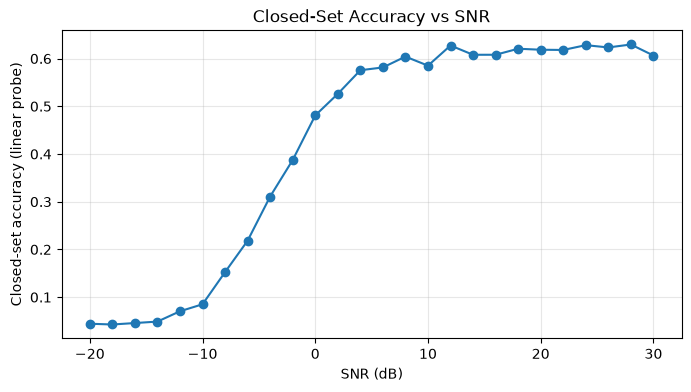

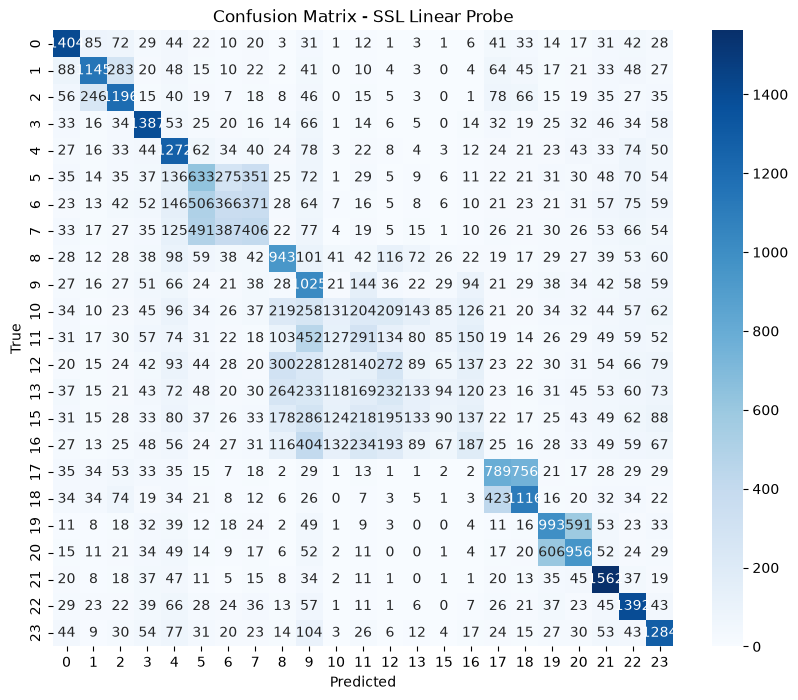

In [63]:
# --- Freeze encoder, extract embeddings, linear probe for closed-set accuracy ---

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier
import seaborn as sns

@torch.no_grad()
def get_embeddings(encoder, X, batch_size=512):
    encoder.eval()
    X_t = torch.from_numpy(X).float().permute(0, 2, 1)
    embs = []
    for i in range(0, len(X_t), batch_size):
        batch = X_t[i:i+batch_size].to(device)
        embs.append(encoder(batch).cpu().numpy())
    return np.concatenate(embs, axis=0)

# Extract embeddings
print("Extracting embeddings...")
emb_train = get_embeddings(encoder, X_train)
emb_val = get_embeddings(encoder, X_val)
emb_test = get_embeddings(encoder, X_test)
emb_unk = get_embeddings(encoder, X_unk) 

# Train linear probe with validation
print("\nTraining linear probe...")
best_acc = 0
best_probe = None
for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    probe = LogisticRegression(max_iter=2000, random_state=SEED, C=C)
    probe.fit(emb_train, y_train)
    val_acc = accuracy_score(y_val, probe.predict(emb_val))
    print(f"C={C:6.1f}, Val accuracy: {val_acc:.4f}")
    if val_acc > best_acc:
        best_acc = val_acc
        best_probe = probe

probe = best_probe
probe_pred = probe.predict(emb_test)
test_acc = accuracy_score(y_test, probe_pred)

print(f"\n--- Final Results ---")
print(f"Linear probe closed-set accuracy: {test_acc:.4f}")
print(f"Validation accuracy: {best_acc:.4f}")

# Compare with random baseline
dummy = DummyClassifier(strategy='most_frequent').fit(emb_train, y_train)
print(f"Random baseline: {accuracy_score(y_test, dummy.predict(emb_test)):.4f}")

# Per-class accuracy
print("\n--- Per-class accuracy ---")
for class_id in np.unique(y_test):
    mask = y_test == class_id
    acc = accuracy_score(y_test[mask], probe_pred[mask])
    print(f"Class {class_id:2d}: {acc:.4f}")

# SNR-stratified closed-set accuracy
snr_bins = sorted(np.unique(snr_test))
closed_set_by_snr = []
for s in snr_bins:
    mask = snr_test == s
    acc = accuracy_score(y_test[mask], probe_pred[mask]) if mask.sum() > 0 else np.nan
    closed_set_by_snr.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(snr_bins, closed_set_by_snr, marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Closed-set accuracy (linear probe)")
plt.title("Closed-Set Accuracy vs SNR")
plt.grid(alpha=0.3)
plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, probe_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SSL Linear Probe')
plt.show()

In [66]:
# --- Open-set scoring: Mahalanobis distance ---
# Uses embeddings already extracted: emb_train, emb_test, emb_unk

from sklearn.covariance import EmpiricalCovariance
from sklearn.metrics import roc_auc_score
import numpy as np

# --- Define function ---

def mahalanobis_score(embs, class_means, precision):
    """Min Mahalanobis distance to any known-class mean."""
    dists = []
    for c, mu in class_means.items():
        diff = embs - mu
        d = np.einsum("ij,jk,ik->i", diff, precision, diff)
        dists.append(d)
    return np.stack(dists, axis=1).min(axis=1)

# --- Use EXISTING embeddings (no re-extraction!) ---

print(f"Using existing embeddings:")
print(f"  Train: {emb_train.shape}")
print(f"  Test:  {emb_test.shape}")
print(f"  Unknown: {emb_unk.shape}")

# Compute class means from TRAIN embeddings
class_means = {c: emb_train[y_train == c].mean(axis=0) for c in KNOWN_IDS}

# Compute precision matrix for Mahalanobis
centered = np.concatenate([emb_train[y_train == c] - class_means[c] for c in KNOWN_IDS], axis=0)
cov_estimator = EmpiricalCovariance().fit(centered)
precision = cov_estimator.precision_

# --- Mahalanobis distance ---
print("Computing Mahalanobis scores...")
score_known = mahalanobis_score(emb_test, class_means, precision)
score_unk = mahalanobis_score(emb_unk, class_means, precision)

# Create labels: 0 for known (test), 1 for unknown (ood)
ood_labels = np.concatenate([np.zeros(len(score_known)), np.ones(len(score_unk))])
scores = np.concatenate([score_known, score_unk])

auroc = roc_auc_score(ood_labels, scores)
thr = np.percentile(score_known, 95)
fpr95 = (score_unk <= thr).mean()

print(f"\n--- Open-Set Detection Results ---")
print(f"Mahalanobis distance AUROC: {auroc:.4f} | FPR95: {fpr95:.4f}")

Using existing embeddings:
  Train: (209300, 128)
  Test:  (44850, 128)
  Unknown: (13000, 128)
Computing Mahalanobis scores...

--- Open-Set Detection Results ---
Mahalanobis distance AUROC: 0.3674 | FPR95: 1.0000


Using existing embeddings:
Train: (209300, 128)
Test : (44850, 128)
Unknown: (13000, 128)
Number of class means: 23
Precision shape: (128, 128)

Computing Mahalanobis distances...

--- Mahalanobis Statistics ---
Known distance: mean=61.9788, median=30.4477, 95th=226.2809
OOD distance:   mean=26.3824, median=25.3582, 95th=40.5424

95% known threshold: 226.2809

--- Open-Set Detection ---
AUROC : 0.3407
FPR95 : 1.0000


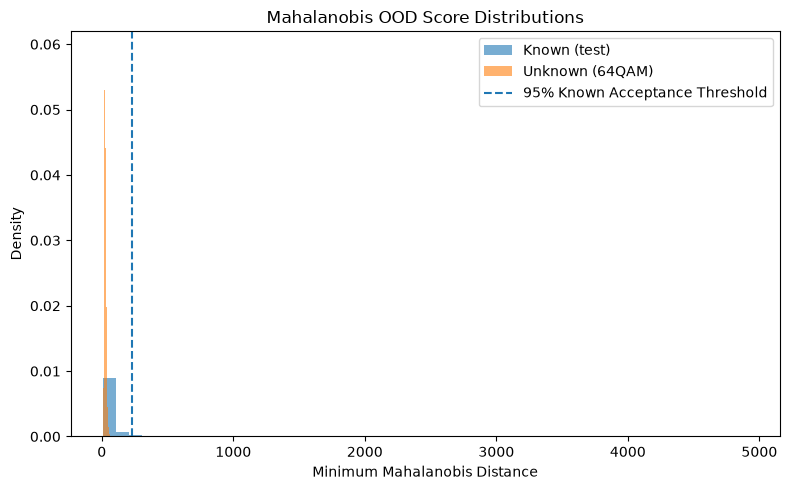

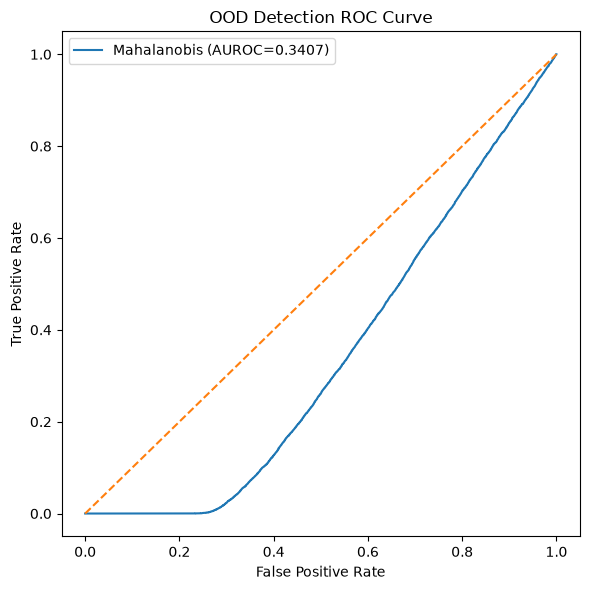

In [79]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.covariance import LedoitWolf
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Mahalanobis distance
# ============================================================

def mahalanobis_distance(embs, class_means, precision):
    """
    Minimum squared Mahalanobis distance to any known-class mean.
    HIGHER = more OOD-like
    LOWER  = more known-like
    """
    dists = []

    for c, mu in class_means.items():
        diff = embs - mu
        d = np.einsum("ij,jk,ik->i", diff, precision, diff)
        dists.append(d)

    return np.stack(dists, axis=1).min(axis=1)


# ============================================================
# 2. Inspect embeddings
# ============================================================

print("Using existing embeddings:")
print("Train:", emb_train.shape)
print("Test :", emb_test.shape)
print("Unknown:", emb_unk.shape)


# ============================================================
# 3. Compute class means
# ============================================================

class_means = {}

for c in KNOWN_IDS:
    mask = (y_train == c)

    if mask.sum() == 0:
        print(f"WARNING: no training samples for class {c}")
        continue

    class_means[c] = emb_train[mask].mean(axis=0)

print("Number of class means:", len(class_means))


# ============================================================
# 4. Pooled covariance
# ============================================================

centered = np.concatenate(
    [
        emb_train[y_train == c] - class_means[c]
        for c in class_means
    ],
    axis=0
)

cov_estimator = LedoitWolf().fit(centered)
precision = cov_estimator.precision_

print("Precision shape:", precision.shape)


# ============================================================
# 5. Compute OOD scores
# ============================================================

print("\nComputing Mahalanobis distances...")

dist_known = mahalanobis_distance(
    emb_test,
    class_means,
    precision
)

dist_unk = mahalanobis_distance(
    emb_unk,
    class_means,
    precision
)

# HIGHER = MORE OOD
scores = np.concatenate([
    dist_known,
    dist_unk
])

labels = np.concatenate([
    np.zeros(len(dist_known)),  # known
    np.ones(len(dist_unk))      # OOD
])


# ============================================================
# 6. Correct AUROC
# ============================================================

auroc = roc_auc_score(labels, scores)


# ============================================================
# 7. FPR95
# ============================================================

# We want 95% of KNOWN samples to be accepted.
# Since higher distance = OOD:
# threshold = 95th percentile of KNOWN distances.

threshold_95 = np.percentile(dist_known, 95)

# Known accepted if distance <= threshold.
# OOD incorrectly accepted = distance <= threshold.

fpr95 = np.mean(dist_unk <= threshold_95)


# ============================================================
# 8. Print statistics
# ============================================================

print("\n--- Mahalanobis Statistics ---")

print(
    f"Known distance: "
    f"mean={dist_known.mean():.4f}, "
    f"median={np.median(dist_known):.4f}, "
    f"95th={np.percentile(dist_known, 95):.4f}"
)

print(
    f"OOD distance:   "
    f"mean={dist_unk.mean():.4f}, "
    f"median={np.median(dist_unk):.4f}, "
    f"95th={np.percentile(dist_unk, 95):.4f}"
)

print(f"\n95% known threshold: {threshold_95:.4f}")

print("\n--- Open-Set Detection ---")
print(f"AUROC : {auroc:.4f}")
print(f"FPR95 : {fpr95:.4f}")


# ============================================================
# 9. Plot distributions
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    dist_known,
    bins=50,
    alpha=0.6,
    label="Known (test)",
    density=True
)

plt.hist(
    dist_unk,
    bins=50,
    alpha=0.6,
    label="Unknown (64QAM)",
    density=True
)

plt.axvline(
    threshold_95,
    linestyle="--",
    label="95% Known Acceptance Threshold"
)

plt.xlabel("Minimum Mahalanobis Distance")
plt.ylabel("Density")
plt.title("Mahalanobis OOD Score Distributions")
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 10. ROC curve
# ============================================================

fpr, tpr, thresholds = roc_curve(labels, scores)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Mahalanobis (AUROC={auroc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("OOD Detection ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

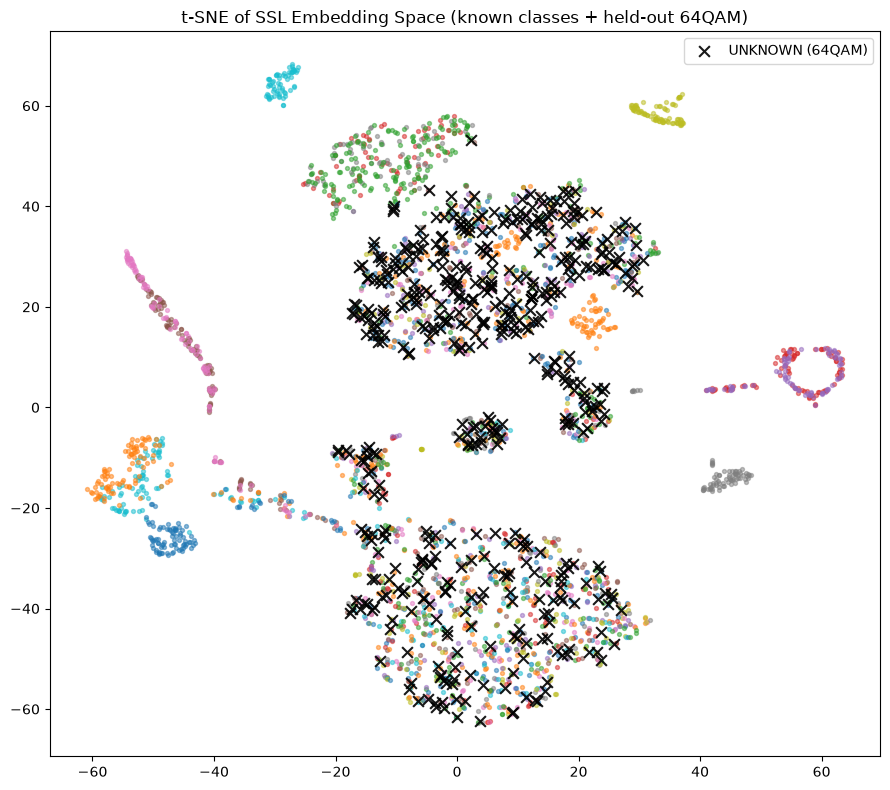

In [71]:
# --- t-SNE of SSL embedding space: known classes + the held-out unknown class ---
# (Use a subsample for speed -- t-SNE is O(n^2)-ish.)

from sklearn.manifold import TSNE

N_TSNE = 3000
rng = np.random.default_rng(SEED)

idx_known = rng.choice(len(emb_test), size=min(N_TSNE, len(emb_test)), replace=False)
idx_unk = rng.choice(len(emb_unk), size=min(500, len(emb_unk)), replace=False)

tsne_input = np.concatenate([emb_test[idx_known], emb_unk[idx_unk]], axis=0)
tsne_labels = np.concatenate([
    [CLASS_NAMES[c] for c in y_test[idx_known]],
    ["UNKNOWN (64QAM)"] * len(idx_unk)
])

tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, init="pca")
tsne_out = tsne.fit_transform(tsne_input)

plt.figure(figsize=(9, 8))
for lbl in np.unique(tsne_labels):
    mask = tsne_labels == lbl
    is_unknown = lbl.startswith("UNKNOWN")
    plt.scatter(tsne_out[mask, 0], tsne_out[mask, 1],
                s=60 if is_unknown else 8,
                marker="x" if is_unknown else "o",
                c="black" if is_unknown else None,
                alpha=0.9 if is_unknown else 0.5,
                label=lbl if is_unknown else None)
plt.title("t-SNE of SSL Embedding Space (known classes + held-out 64QAM)")
plt.legend()
plt.tight_layout()
plt.show()
